In [4]:
# Loading the data

import pandas as pd

# Importing the dataset
dataset = pd.read_csv('Dataset/franciellevargas-FactNews-786c504/dataset/factnews_dataset.csv')

print(dataset['classe'].value_counts())

dataset.head()

# 0: Factual
# -1: Quote
# 1: Bias

classe
 0    4242
-1    1391
 1     558
Name: count, dtype: int64


,file,id_sente,id_article,domain,year,sentences,classe
0,C1_Estadao_04-08-2006_05h54,1,c1e,world,2006,"""Não houve sobreviventes"", disse Okala.",-1
1,C1_Estadao_04-08-2006_05h54,2,c1e,world,2006,As vítimas do acidente foram 14 passageiros e ...,0
2,C1_Estadao_04-08-2006_05h54,3,c1e,world,2006,"O avião explodiu e se incendiou, acrescentou o...",0
3,C1_Estadao_04-08-2006_05h54,4,c1e,world,2006,"O porta-voz informou que o avião, um Soviet An...",0
4,C1_Estadao_04-08-2006_05h54,5,c1e,world,2006,"Segundo fontes aeroportuárias, os membros da t...",0


C:\Users\Paulo Alexandre\AppData\Local\Temp\ipykernel_14596\1978596500.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=dataset, palette='viridis')


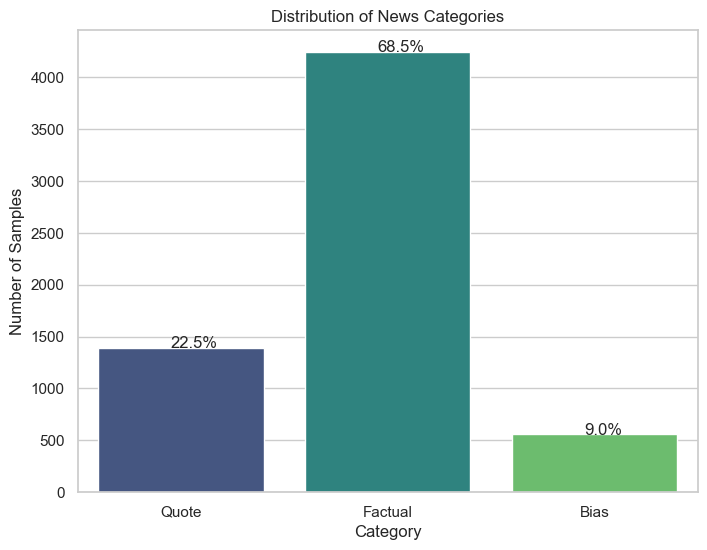

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping for better readability
class_map = {0: 'Factual', -1: 'Quote', 1: 'Bias'}
dataset['label'] = dataset['classe'].map(class_map)

# Set the style
sns.set(style="whitegrid")

# Create a count plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='label', data=dataset, palette='viridis')
plt.title('Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Number of Samples')

# Add percentages on top of bars
total = len(dataset)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), size = 12)

plt.show()

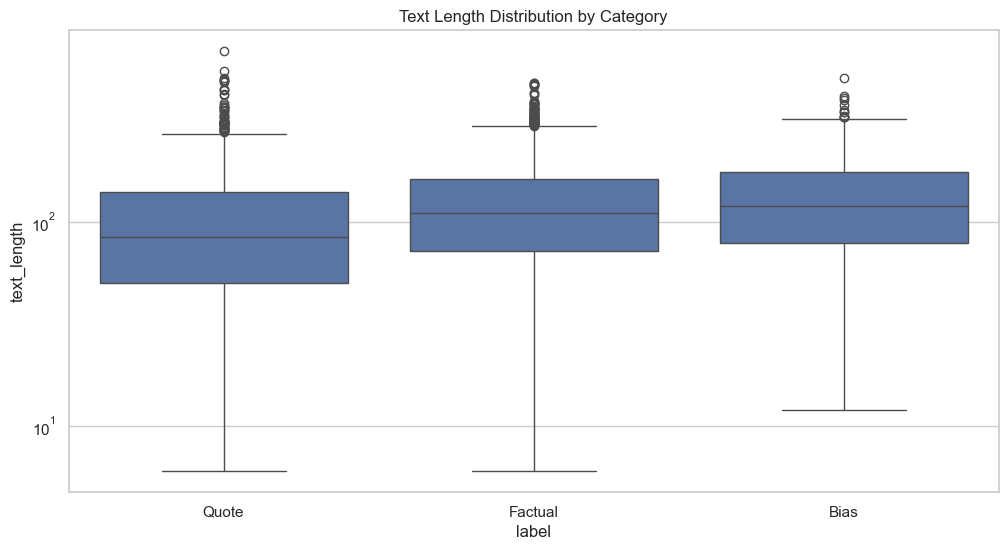

In [10]:
# Calculate length of the news text
dataset['text_length'] = dataset['sentences'].apply(len)
dataset['word_count'] = dataset['sentences'].apply(lambda x: len(str(x).split()))

# Visualize text length distribution per class
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='text_length', data=dataset)
plt.title('Text Length Distribution by Category')
plt.yscale('log') # Use log scale if there are many outliers
plt.show()

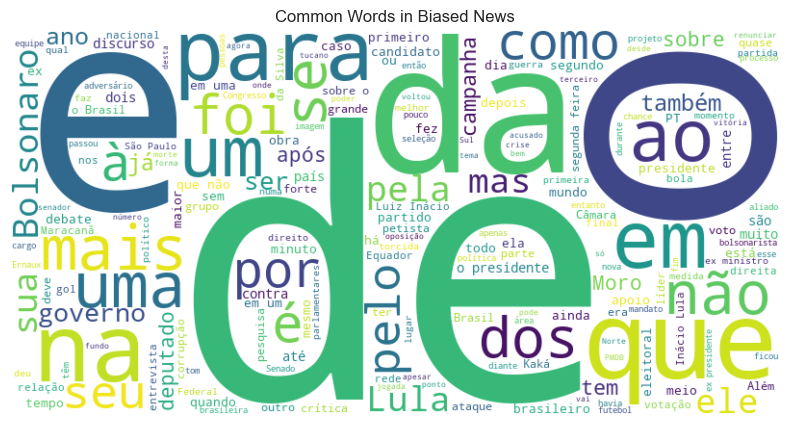

In [12]:
from wordcloud import WordCloud

def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Example: WordCloud for Bias news
bias_text = " ".join(dataset[dataset['classe'] == 1]['sentences'])
plot_wordcloud(bias_text, "Common Words in Biased News")

[nltk_data] Downloading package stopwords to C:\Users\Paulo
[nltk_data]     Alexandre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


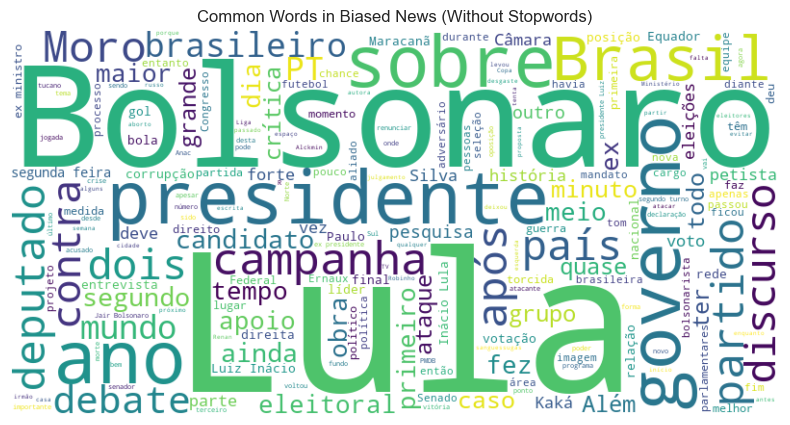

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(text, title, stop_words_list=None):
    # Pass the stop_words list directly into the WordCloud constructor
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        stopwords=stop_words_list,  # This is the key change
        colormap='viridis'
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# 1. Ensure you have the Portuguese list ready
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
pt_stopwords = set(stopwords.words('portuguese'))

# 3. Generate the cloud
bias_text = " ".join(dataset[dataset['classe'] == 1]['sentences'].dropna().astype(str))
plot_wordcloud(bias_text, "Common Words in Biased News (Without Stopwords)", stop_words_list=pt_stopwords)

[nltk_data] Downloading package stopwords to C:\Users\Paulo
[nltk_data]     Alexandre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Paulo Alexandre\AppData\Local\Temp\ipykernel_14596\1372281108.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Trigram', data=df_fact, ax=ax1, palette='Blues_r')
C:\Users\Paulo Alexandre\AppData\Local\Temp\ipykernel_14596\1372281108.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Trigram', data=df_bias, ax=ax2, palette='Reds_r')
C:\Users\Paulo Alexandre\AppData\Local\Temp\ipykernel_14596\1372281108.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

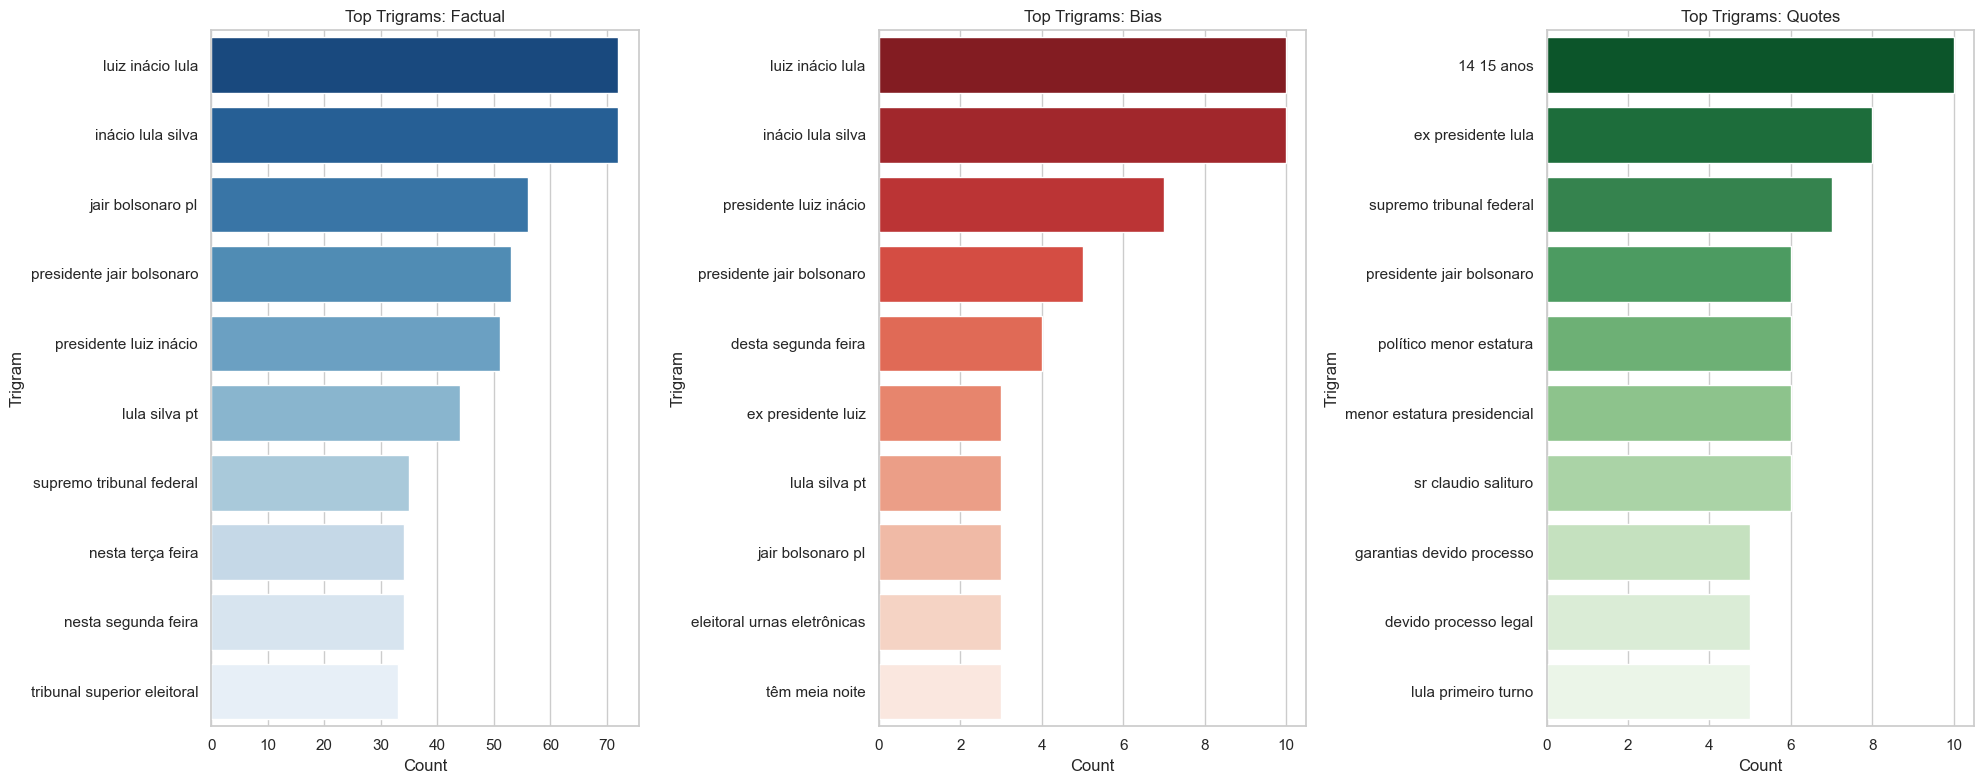

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

pt_stopwords = stopwords.words('portuguese')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))

# Helper to get data for subplots
def get_trigram_data(corpus, n=10):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words=pt_stopwords).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = sorted([(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()], 
                        key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame(words_freq, columns=['Trigram', 'Count'])

# Data for Factual
df_fact = get_trigram_data(dataset[dataset['classe'] == 0]['sentences'].dropna())
sns.barplot(x='Count', y='Trigram', data=df_fact, ax=ax1, palette='Blues_r')
ax1.set_title('Top Trigrams: Factual')

# Data for Bias
df_bias = get_trigram_data(dataset[dataset['classe'] == 1]['sentences'].dropna())
sns.barplot(x='Count', y='Trigram', data=df_bias, ax=ax2, palette='Reds_r')
ax2.set_title('Top Trigrams: Bias')

# Data for quotes
df_quotes = get_trigram_data(dataset[dataset['classe'] == -1]['sentences'].dropna())
sns.barplot(x='Count', y='Trigram', data=df_quotes, ax=ax3, palette='Greens_r')
ax3.set_title('Top Trigrams: Quotes')

plt.tight_layout()
plt.show()

C:\Users\Paulo Alexandre\AppData\Local\Temp\ipykernel_14596\1985098100.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=df_fact, ax=ax1, palette='Blues_r')
C:\Users\Paulo Alexandre\AppData\Local\Temp\ipykernel_14596\1985098100.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=df_bias, ax=ax2, palette='Reds_r')
C:\Users\Paulo Alexandre\AppData\Local\Temp\ipykernel_14596\1985098100.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=df_quotes, ax=ax3, p

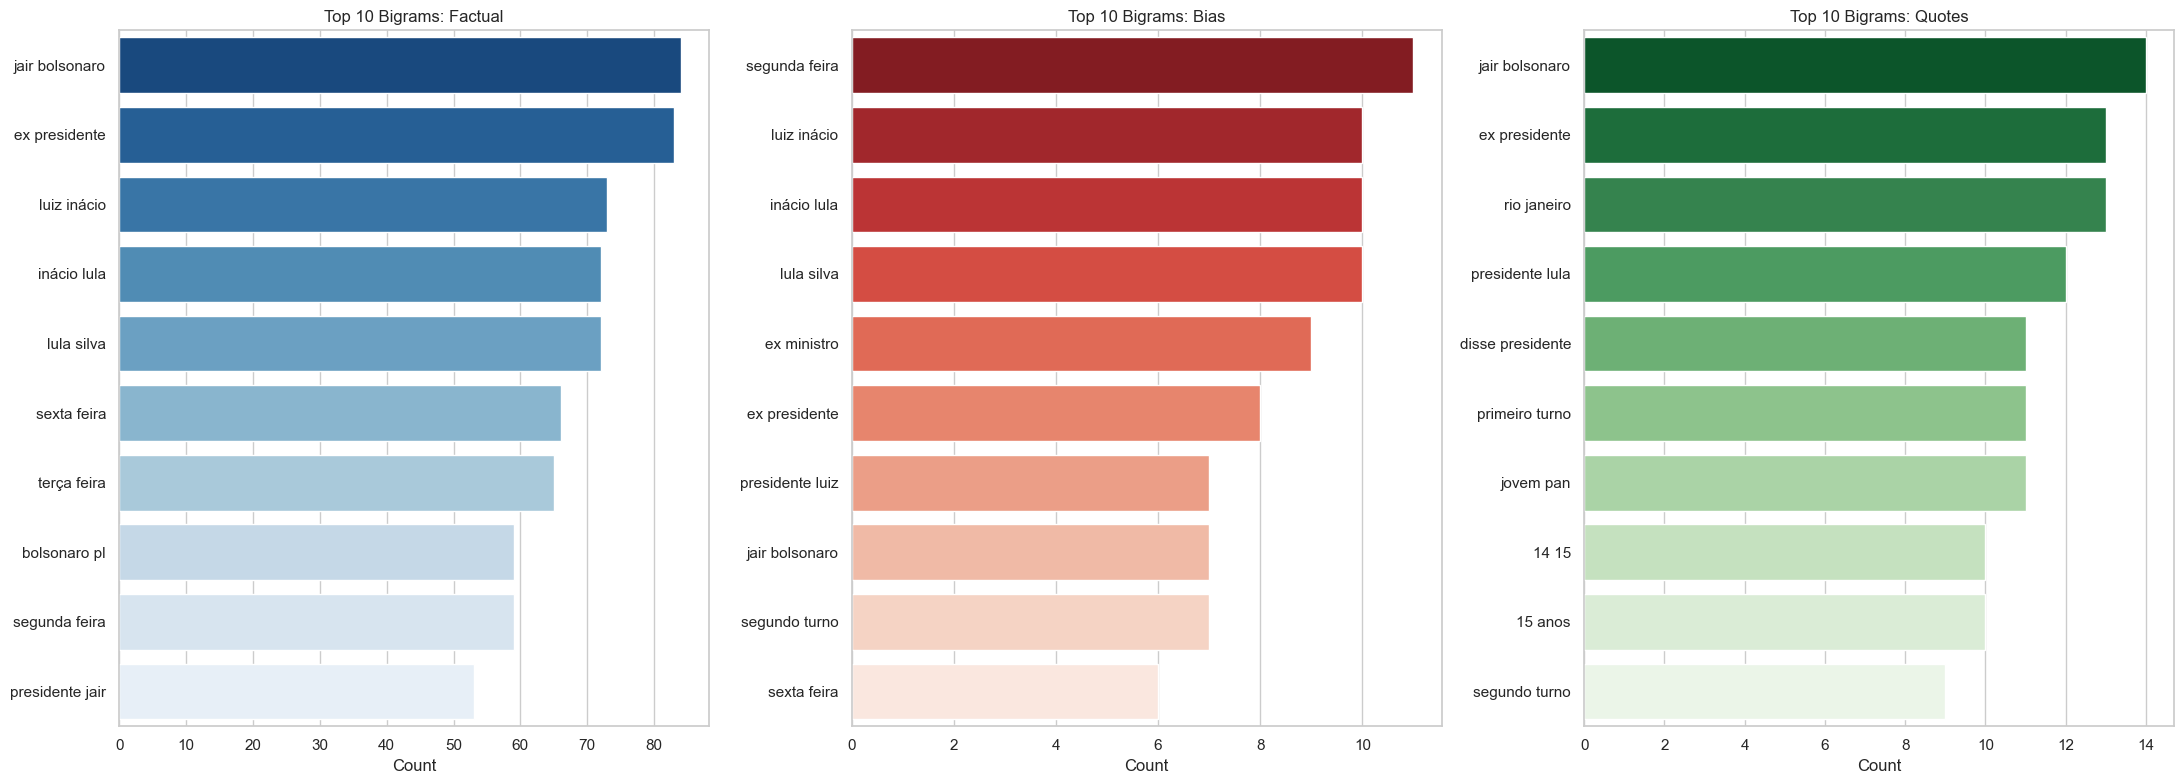

In [44]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create subplots for the three categories
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# 2. Updated Helper function to get Bigram data
def get_bigram_data(corpus, n=10):
    # Changed ngram_range to (2, 2) for Bigrams
    vec = CountVectorizer(ngram_range=(2, 2), stop_words=pt_stopwords).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    # Extract frequencies
    words_freq = sorted([(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()], 
                        key=lambda x: x[1], reverse=True)[:n]
    
    return pd.DataFrame(words_freq, columns=['Bigram', 'Count'])

# 3. Process and Plot Factual
df_fact = get_bigram_data(dataset[dataset['classe'] == 0]['sentences'].dropna())
sns.barplot(x='Count', y='Bigram', data=df_fact, ax=ax1, palette='Blues_r')
ax1.set_title('Top 10 Bigrams: Factual')
ax1.set_ylabel('')

# 4. Process and Plot Bias
df_bias = get_bigram_data(dataset[dataset['classe'] == 1]['sentences'].dropna())
sns.barplot(x='Count', y='Bigram', data=df_bias, ax=ax2, palette='Reds_r')
ax2.set_title('Top 10 Bigrams: Bias')
ax2.set_ylabel('')

# 5. Process and Plot Quotes
df_quotes = get_bigram_data(dataset[dataset['classe'] == -1]['sentences'].dropna())
sns.barplot(x='Count', y='Bigram', data=df_quotes, ax=ax3, palette='Greens_r')
ax3.set_title('Top 10 Bigrams: Quotes')
ax3.set_ylabel('')

plt.tight_layout()
plt.show()

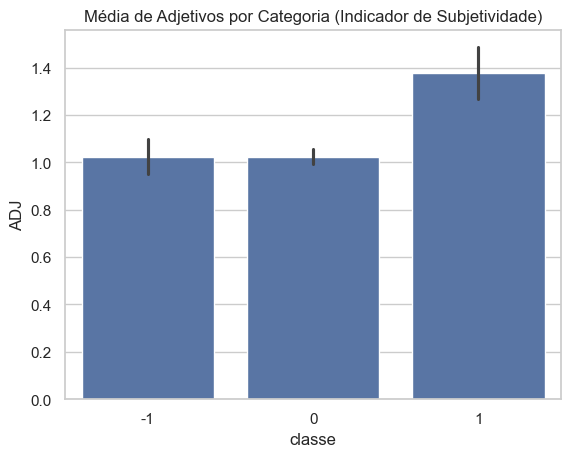

In [41]:
def analyze_pos_portuguese(text):
    doc = nlp(str(text))
    # Count Adjectives (ADJ) and Adverbs (ADV) - high density often suggests bias
    counts = {"ADJ": 0, "ADV": 0, "NOUN": 0, "VERB": 0}
    for token in doc:
        if token.pos_ in counts:
            counts[token.pos_] += 1
    return counts

# Example: Compare Average Adjective Count
pos_data = dataset['sentences'].apply(analyze_pos_portuguese).apply(pd.Series)
dataset = pd.concat([dataset, pos_data], axis=1)

sns.barplot(x='classe', y='ADJ', data=dataset)
plt.title('Média de Adjetivos por Categoria (Indicador de Subjetividade)')
plt.show()

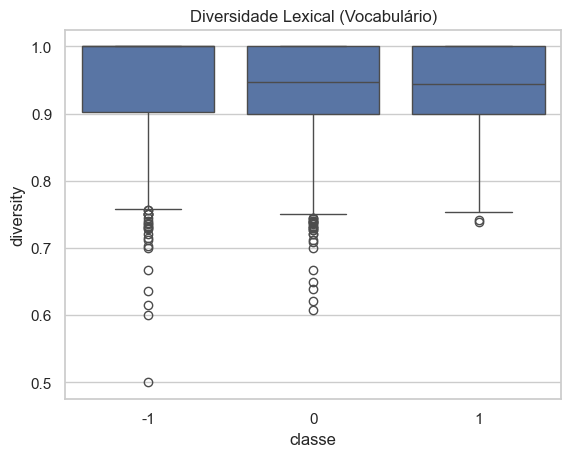

In [42]:
def lexical_diversity(text):
    words = str(text).lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

dataset['diversity'] = dataset['sentences'].apply(lexical_diversity)
sns.boxplot(x='classe', y='diversity', data=dataset)
plt.title('Diversidade Lexical (Vocabulário)')
plt.show()

# Preprocessing

In [9]:
# Cleaning the text

import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

corpus = []
ps = PorterStemmer()
for i in range(0,1000):
    # get sentence and remove non alpha chars
    sentence = re.sub('[^a-zA-Z]', ' ', dataset['sentences'][i])
    # to lower-case and tokenize
    sentence = sentence.lower().split()
    # stemming and stop word removal
    sentence = ' '.join([ps.stem(w) for w in sentence if not w in set(stopwords.words('portuguese'))])
    corpus.append(sentence)

In [11]:
# Creating a bag-of-words model

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features = 1500)
X = vectorizer.fit_transform(corpus).toarray()
y = dataset['classe']

print(X.shape, y.shape)

(1000, 1500) (6191,)
